In [1]:
"""
Feature Engineering - Preparación de Datos para Machine Learning
"""

import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.loader import StatsBombLoader
from src.data.preprocessing import PassPreprocessor
from src.data.feature_engineering import FeatureExtractor

pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')

print("✅ Librerías cargadas")

✅ Librerías cargadas


In [2]:
# Cargar partidos
loader = StatsBombLoader()
matches = loader.get_matches(competition_id=11, season_id=90)

# Seleccionar partidos de Barcelona (primeros 5 para este ejemplo)
barcelona_matches = matches[
    (matches['home_team'] == 'Barcelona') | 
    (matches['away_team'] == 'Barcelona')
].head(5)

print(f"📊 Partidos seleccionados: {len(barcelona_matches)}")
print(barcelona_matches[['match_date', 'home_team', 'away_team', 'home_score', 'away_score']])

C:\Users\xurzy\Desktop\TFG\tfg-football-tactical-modeling\venv\Lib\site-packages\statsbombpy\api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


✅ Partidos guardados en: data/raw/matches_11_90.csv
📊 Partidos seleccionados: 5
   match_date         home_team   away_team  home_score  away_score
0  2020-10-31  Deportivo Alavés   Barcelona           1           1
1  2021-01-09           Granada   Barcelona           0           4
2  2021-05-16         Barcelona  Celta Vigo           1           2
3  2021-02-07        Real Betis   Barcelona           2           3
4  2021-03-06           Osasuna   Barcelona           0           2


In [3]:
preprocessor = PassPreprocessor()
matches_data = []

for idx, match_row in barcelona_matches.iterrows():
    match_id = match_row['match_id']
    print(f"\n{'='*60}")
    print(f"Procesando: {match_row['home_team']} vs {match_row['away_team']}")
    print(f"{'='*60}")
    
    try:
        events, _ = loader.load_match_data(match_id)
        passes_clean = preprocessor.preprocess_full_pipeline(events)
        
        # Añadir ambos equipos
        matches_data.append((match_id, passes_clean, match_row['home_team']))
        matches_data.append((match_id, passes_clean, match_row['away_team']))
        
    except Exception as e:
        print(f"❌ Error: {e}")

print(f"\n✅ Total de instancias preparadas: {len(matches_data)}")


Procesando: Deportivo Alavés vs Barcelona


C:\Users\xurzy\Desktop\TFG\tfg-football-tactical-modeling\venv\Lib\site-packages\statsbombpy\api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


✅ Eventos guardados en: data/raw/events_3773386.csv
📊 Partido 3773386:
   - Total eventos: 3891
   - Total pases: 1118

🧹 INICIANDO PIPELINE DE PREPROCESAMIENTO

📊 Eventos totales: 3891
✅ Pases encontrados: 1118
🧹 Pases después de eliminar nulos en player/team: 1118
✅ Precisión de pase: 83.90%
🧹 Pases después de filtrar por distancia: 1118 (eliminados: 0)
✅ Normalización temporal completada
🧹 Pases con receptor válido: 1060 (eliminados: 58)

✅ PREPROCESAMIENTO COMPLETADO: 1060 pases válidos


Procesando: Granada vs Barcelona


C:\Users\xurzy\Desktop\TFG\tfg-football-tactical-modeling\venv\Lib\site-packages\statsbombpy\api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


✅ Eventos guardados en: data/raw/events_3773565.csv
📊 Partido 3773565:
   - Total eventos: 3775
   - Total pases: 1153

🧹 INICIANDO PIPELINE DE PREPROCESAMIENTO

📊 Eventos totales: 3775
✅ Pases encontrados: 1153
🧹 Pases después de eliminar nulos en player/team: 1153
✅ Precisión de pase: 88.46%
🧹 Pases después de filtrar por distancia: 1153 (eliminados: 0)
✅ Normalización temporal completada
🧹 Pases con receptor válido: 1142 (eliminados: 11)

✅ PREPROCESAMIENTO COMPLETADO: 1142 pases válidos


Procesando: Barcelona vs Celta Vigo


...

✅ Eventos guardados en: data/raw/events_3773457.csv
📊 Partido 3773457:
   - Total eventos: 4205
   - Total pases: 1201

🧹 INICIANDO PIPELINE DE PREPROCESAMIENTO

📊 Eventos totales: 4205
✅ Pases encontrados: 1201
🧹 Pases después de eliminar nulos en player/team: 1201
✅ Precisión de pase: 86.93%
🧹 Pases después de filtrar por distancia: 1201 (eliminados: 0)
✅ Normalización temporal completada
🧹 Pases con receptor válido: 1153 (eliminados: 48)

✅ PREPROCESAMIENTO COMPLETADO: 1153 pases válidos


Procesando: Real Betis vs Barcelona


C:\Users\xurzy\Desktop\TFG\tfg-football-tactical-modeling\venv\Lib\site-packages\statsbombpy\api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


✅ Eventos guardados en: data/raw/events_3773631.csv
📊 Partido 3773631:
   - Total eventos: 4004
   - Total pases: 1184

🧹 INICIANDO PIPELINE DE PREPROCESAMIENTO

📊 Eventos totales: 4004
✅ Pases encontrados: 1184
🧹 Pases después de eliminar nulos en player/team: 1184
✅ Precisión de pase: 87.58%
🧹 Pases después de filtrar por distancia: 1184 (eliminados: 0)
✅ Normalización temporal completada
🧹 Pases con receptor válido: 1176 (eliminados: 8)

✅ PREPROCESAMIENTO COMPLETADO: 1176 pases válidos


Procesando: Osasuna vs Barcelona


C:\Users\xurzy\Desktop\TFG\tfg-football-tactical-modeling\venv\Lib\site-packages\statsbombpy\api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


✅ Eventos guardados en: data/raw/events_3773665.csv
📊 Partido 3773665:
   - Total eventos: 4188
   - Total pases: 1208

🧹 INICIANDO PIPELINE DE PREPROCESAMIENTO

📊 Eventos totales: 4188
✅ Pases encontrados: 1208
🧹 Pases después de eliminar nulos en player/team: 1208
✅ Precisión de pase: 85.43%
🧹 Pases después de filtrar por distancia: 1208 (eliminados: 0)
✅ Normalización temporal completada
🧹 Pases con receptor válido: 1169 (eliminados: 39)

✅ PREPROCESAMIENTO COMPLETADO: 1169 pases válidos


✅ Total de instancias preparadas: 10


In [4]:
# Extraer Features
extractor = FeatureExtractor()

# Crear dataset completo
df_features = extractor.create_dataset_from_matches(
    matches_data, 
    include_temporal=True
)

# Resumen
extractor.print_feature_summary(df_features)


🏗️  CONSTRUYENDO DATASET DE FEATURES

[1/10] Match ID: 3773386 - Team: Deportivo Alavés

🔧 Extrayendo features para Deportivo Alavés...
   - Estadísticas de pases...
   - Grafo estático...

🔨 Construyendo grafo de pases (peso: frequency)...
✅ Grafo construido:
   - Nodos (jugadores): 16
   - Aristas (conexiones): 98
📊 Calculando coeficiente de clustering...
✅ Clustering promedio: 0.1846

📊 Calculando métricas de centralidad...
✅ Métricas de centralidad calculadas
   - Grafos dinámicos...

🔨 Construyendo grafos dinámicos...
✅ Creadas 46 ventanas temporales
   - Tamaño de ventana: 5 min
   - Paso: 2 min

🔨 Construyendo grafo de pases (peso: frequency)...
✅ Grafo construido:
   - Nodos (jugadores): 10
   - Aristas (conexiones): 23

🔨 Construyendo grafo de pases (peso: frequency)...
✅ Grafo construido:
   - Nodos (jugadores): 11
   - Aristas (conexiones): 27

🔨 Construyendo grafo de pases (peso: frequency)...
✅ Grafo construido:
   - Nodos (jugadores): 11
   - Aristas (conexiones): 17

🔨 

In [5]:
# Ver primeras filas
print("📋 Primeras instancias:")
display(df_features.head())

# Estadísticas descriptivas
print("\n📊 Estadísticas de features (primeras 10 columnas numéricas):")
numeric_cols = df_features.select_dtypes(include=[np.number]).columns[:10]
display(df_features[numeric_cols].describe())

📋 Primeras instancias:


,match_id,team,total_passes,unique_players,unique_recipients,successful_passes,pass_accuracy,avg_pass_distance,max_pass_distance,min_pass_distance,std_pass_distance,total_pass_distance,passes_first_half,passes_second_half,passes_ratio_halves,avg_passes_per_player,max_passes_per_player,std_passes_per_player,static_num_nodes,static_num_edges,static_density,static_avg_degree,static_max_degree,static_min_degree,static_std_degree,static_avg_in_degree,static_max_in_degree,static_avg_out_degree,static_max_out_degree,static_avg_clustering,static_max_clustering,static_std_clustering,static_avg_betweenness,static_max_betweenness,static_std_betweenness,static_avg_pagerank,static_max_pagerank,static_std_pagerank,static_avg_closeness,static_max_closeness,static_is_connected,static_num_components,static_avg_edge_weight,static_max_edge_weight,static_std_edge_weight,static_total_edge_weight,temporal_density_mean,temporal_density_std,temporal_density_max,temporal_density_min,temporal_density_range,temporal_density_variability,temporal_clustering_mean,temporal_clustering_std,temporal_edges_mean,temporal_edges_std,temporal_edges_max,temporal_density_first_half,temporal_density_second_half,temporal_density_change_halves,temporal_clustering_first_half,temporal_clustering_second_half,temporal_density_trend
0,3773386,Deportivo Alavés,210,16,15,154,0.733333,24.261890,88.395588,1.500000,19.889043,5094.996963,118,92,0.779661,13.125,22,6.771263,16,98,0.408333,12.250,20,1,4.930771,6.1250,11,6.1250,12,0.184572,0.312435,0.076889,0.065866,0.290134,0.071301,0.0625,0.119166,0.034234,0.410908,0.576923,1,1,2.142857,7,1.392399,210,0.180997,0.060516,0.333333,0.090909,0.242424,0.052010,0.135166,0.146499,10.279070,5.754193,27,0.160386,0.197314,0.036928,0.101617,0.161725,0.000519
1,3773386,Barcelona,850,16,16,784,0.922353,15.739749,51.685588,1.581139,8.327888,13378.786953,379,471,1.242744,53.125,104,31.185199,16,152,0.633333,19.000,28,3,6.442049,9.5000,14,9.5000,14,0.174252,0.242308,0.037640,0.087222,0.267619,0.070609,0.0625,0.108914,0.028374,0.317958,0.405405,1,1,5.592105,22,4.575903,850,0.309218,0.065833,0.433333,0.154545,0.278788,0.051903,0.220617,0.073190,30.666667,8.538607,48,0.279748,0.334154,0.054407,0.216661,0.223963,0.000928
2,3773565,Granada,316,16,16,255,0.806962,22.718700,88.319024,1.897367,16.331183,7179.109139,191,125,0.654450,19.750,38,10.560934,16,128,0.533333,16.000,23,6,4.847680,8.0000,12,8.0000,13,0.205579,0.281667,0.039000,0.064320,0.231468,0.059414,0.0625,0.102112,0.021165,0.439853,0.555556,1,1,2.468750,16,1.849567,316,0.192501,0.057704,0.392857,0.100000,0.292857,0.045236,0.176824,0.134881,15.272727,6.872133,30,0.195190,0.190046,-0.005144,0.143242,0.207485,-0.000237
3,3773565,Barcelona,826,16,16,765,0.926150,17.889546,67.556347,1.979899,10.106293,14776.765379,339,487,1.436578,51.625,121,30.711290,16,156,0.650000,19.500,30,11,5.700877,9.7500,15,9.7500,15,0.161146,0.246428,0.051728,0.074369,0.164819,0.053859,0.0625,0.122282,0.028256,0.360671,0.483871,1,1,5.294872,23,4.715248,826,0.307835,0.087258,0.522222,0.160714,0.361508,0.065295,0.246170,0.061889,31.913043,11.014790,54,0.270132,0.342397,0.072265,0.217807,0.272170,0.000670
4,3773457,Barcelona,740,16,16,688,0.929730,19.365560,71.758623,1.788854,10.990074,14330.514190,416,324,0.778846,46.250,93,28.746014,16,161,0.670833,20.125,29,7,5.872340,10.0625,15,10.0625,15,0.131531,0.201304,0.035159,0.067741,0.131474,0.030552,0.0625,0.117363,0.031799,0.442366,0.535714,1,1,4.596273,27,4.936087,740,0.296520,0.060646,0.455556,0.189394,0.266162,0.051766,0.220384,0.077894,29.391304,7.237183,46,0.322124,0.273050,-0.049073,0.240209,0.202211,-0.000804



📊 Estadísticas de features (primeras 10 columnas numéricas):


,match_id,total_passes,unique_players,unique_recipients,successful_passes,pass_accuracy,avg_pass_distance,max_pass_distance,min_pass_distance,std_pass_distance
count,1.000000e+01,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000
mean,3.773541e+06,570.000000,15.600000,15.600000,507.100000,0.866676,19.789788,76.045031,1.874373,12.800104
std,1.106875e+02,235.087218,0.966092,0.966092,234.469354,0.065138,2.797945,12.526959,0.313983,3.535432
min,3.773386e+06,210.000000,13.000000,13.000000,154.000000,0.733333,15.739749,51.685588,1.431782,8.327888
25%,3.773457e+06,415.250000,16.000000,16.000000,350.750000,0.829863,17.735271,70.113602,1.633068,10.291115
50%,3.773565e+06,583.500000,16.000000,16.000000,516.000000,0.885171,19.022935,73.249420,1.934837,11.724643
75%,3.773631e+06,751.000000,16.000000,16.000000,688.000000,0.919881,22.308365,87.585535,1.989339,14.761066
max,3.773665e+06,850.000000,16.000000,16.000000,784.000000,0.929730,24.261890,92.362438,2.473863,19.889043


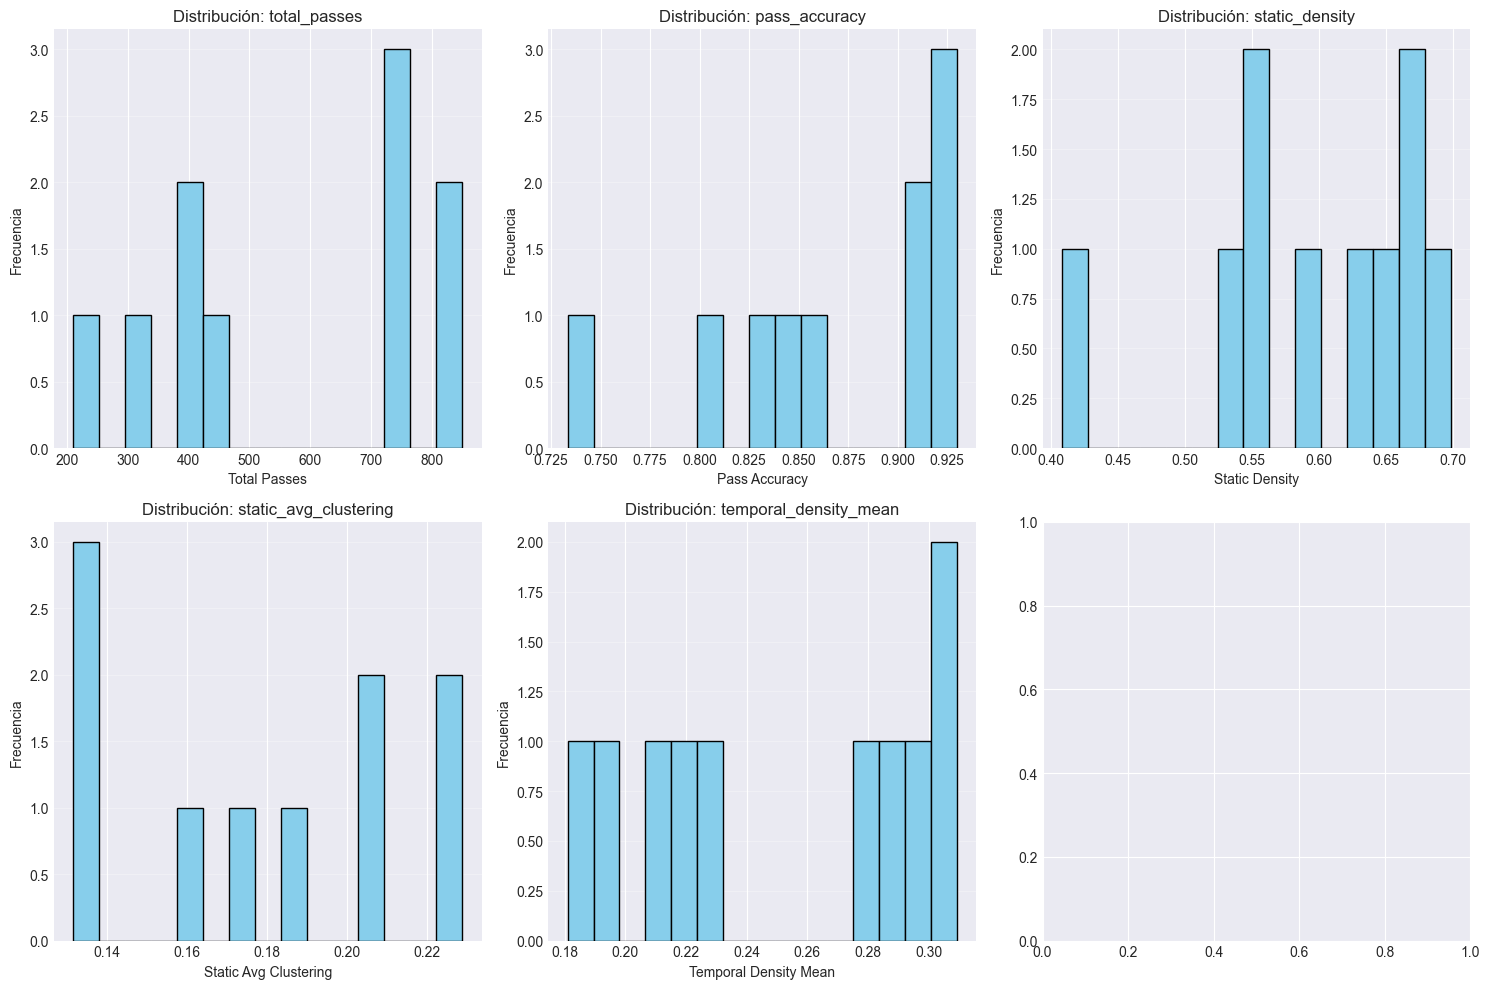

In [6]:
# Visualizar distribución de features clave
features_to_plot = [
    'total_passes', 'pass_accuracy', 'static_density', 
    'static_avg_clustering', 'temporal_density_mean'
]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, feature in enumerate(features_to_plot):
    if feature in df_features.columns:
        axes[idx].hist(df_features[feature], bins=15, color='skyblue', edgecolor='black')
        axes[idx].set_xlabel(feature.replace('_', ' ').title())
        axes[idx].set_ylabel('Frecuencia')
        axes[idx].set_title(f'Distribución: {feature}')
        axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

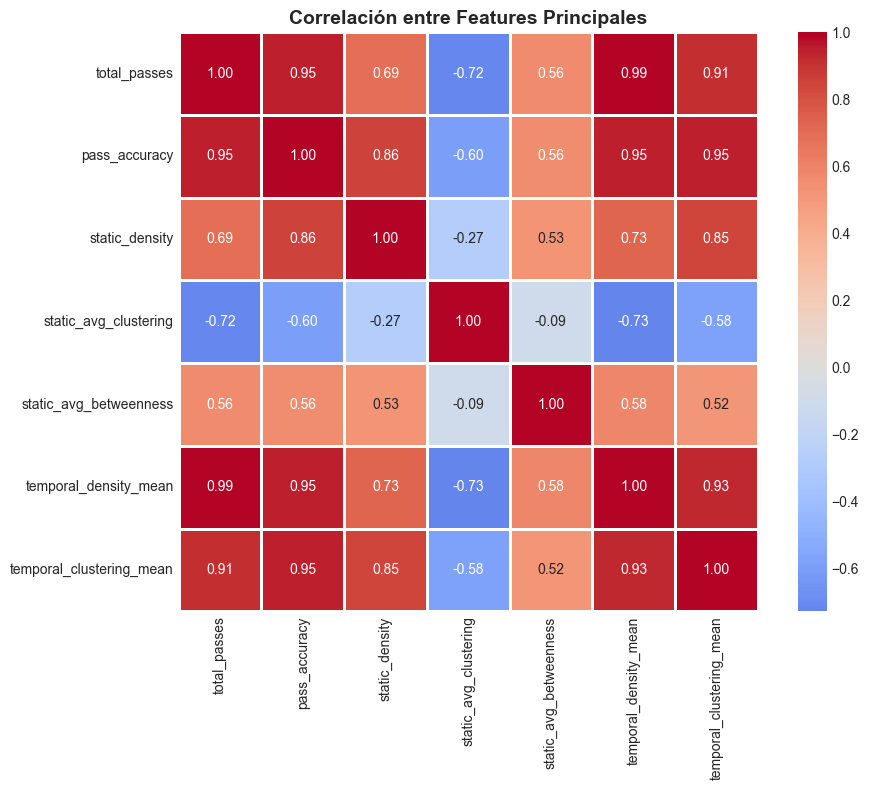

In [7]:
# Calcular correlación entre features principales
features_for_corr = [
    'total_passes', 'pass_accuracy', 'static_density',
    'static_avg_clustering', 'static_avg_betweenness',
    'temporal_density_mean', 'temporal_clustering_mean'
]

available_features = [f for f in features_for_corr if f in df_features.columns]
corr_matrix = df_features[available_features].corr()

# Visualizar
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1)
plt.title('Correlación entre Features Principales', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

C:\Users\xurzy\AppData\Local\Temp\ipykernel_23328\3227170851.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[idx].boxplot(data_to_plot, labels=['Barcelona', 'Otros'])
C:\Users\xurzy\AppData\Local\Temp\ipykernel_23328\3227170851.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[idx].boxplot(data_to_plot, labels=['Barcelona', 'Otros'])
C:\Users\xurzy\AppData\Local\Temp\ipykernel_23328\3227170851.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[idx].boxplot(data_to_plot, labels=['Barcelona', 'Otros'])
C:\Users\xurzy\AppData\Local\Temp\ipykernel_23328\3227170851.py:17: MatplotlibDeprecationWarni

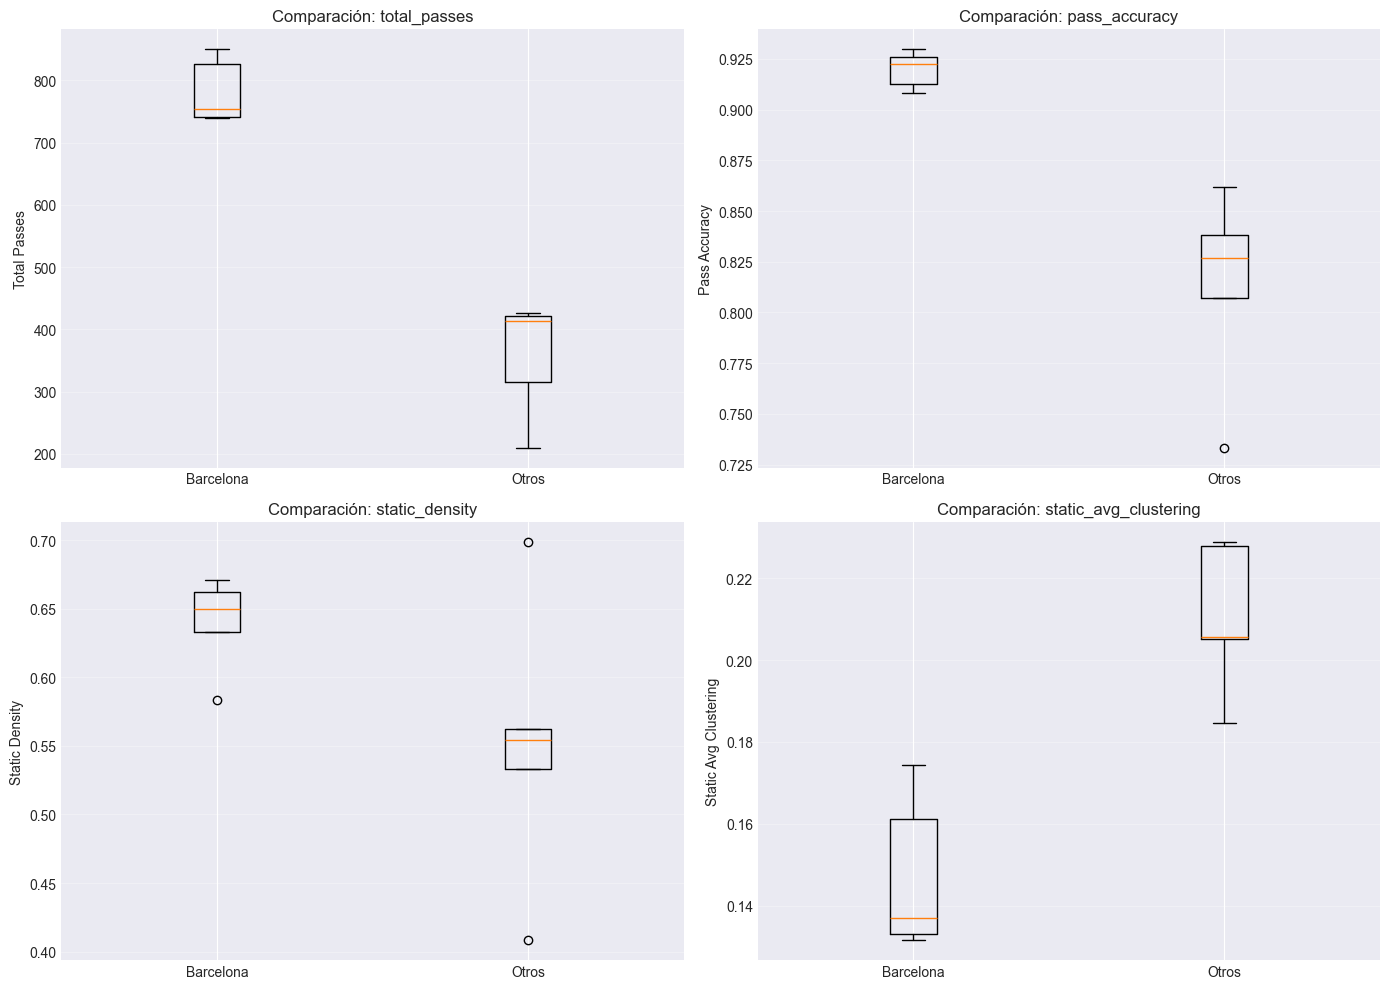

In [8]:
# Comparar Barcelona vs otros equipos en algunas métricas
barcelona_data = df_features[df_features['team'] == 'Barcelona']
others_data = df_features[df_features['team'] != 'Barcelona']

comparison_features = ['total_passes', 'pass_accuracy', 'static_density', 'static_avg_clustering']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, feature in enumerate(comparison_features):
    if feature in df_features.columns:
        data_to_plot = [
            barcelona_data[feature].dropna(),
            others_data[feature].dropna()
        ]
        
        axes[idx].boxplot(data_to_plot, labels=['Barcelona', 'Otros'])
        axes[idx].set_ylabel(feature.replace('_', ' ').title())
        axes[idx].set_title(f'Comparación: {feature}')
        axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
# Exportar dataset de features
extractor.export_features(df_features, 'data/processed/ml_features_dataset.csv')

print(f"✅ Dataset exportado")
print(f"📁 Ubicación: data/processed/ml_features_dataset.csv")
print(f"📊 Shape: {df_features.shape}")

💾 Dataset exportado a: data/processed/ml_features_dataset.csv
✅ Dataset exportado
📁 Ubicación: data/processed/ml_features_dataset.csv
📊 Shape: (10, 63)


In [10]:
# Preparar datos para clasificación
# (Por ahora sin etiquetas reales, solo estructura)

# Normalizar features
df_normalized, norm_params = extractor.normalize_features(df_features)

print("✅ Features normalizadas")
print(f"\nEjemplo de normalización (primera feature):")
feature_name = [col for col in norm_params.keys()][0]
print(f"  Feature: {feature_name}")
print(f"  Media: {norm_params[feature_name]['mean']:.4f}")
print(f"  Desv. Est.: {norm_params[feature_name]['std']:.4f}")

# Mostrar comparación
print(f"\nValores originales vs normalizados:")
print(f"Original: {df_features[feature_name].head().values}")
print(f"Normalizado: {df_normalized[feature_name].head().values}")

✅ 59 features normalizadas
✅ Features normalizadas

Ejemplo de normalización (primera feature):
  Feature: total_passes
  Media: 570.0000
  Desv. Est.: 235.0872

Valores originales vs normalizados:
Original: [210 850 316 826 740]
Normalizado: [-1.53134655  1.19104732 -1.08045007  1.08895755  0.72313587]
